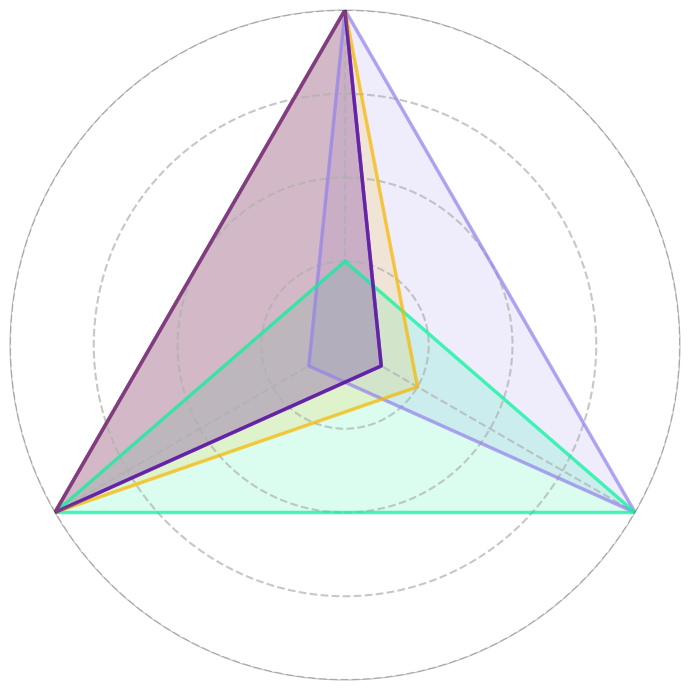

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plotcolorlist = ["#9683ec","#07f49e","#5d16a6","#f7b801","#5d16a6"]

def radar_chart(categories, series, *, title=None, rmin=0, rmax=None):
    N = len(categories)
    if N < 3:
        raise ValueError("Radar charts usually need at least 3 categories.")

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    # Put first axis at the top and go clockwise
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # Move category labels outward so they don't overlap circles
    ax.tick_params(axis="x", pad=20)  # increase if you want more space

    # Radial limits
    if rmax is None:
        all_vals = [v for s in series for v in s["values"]]
        rmax = max(all_vals) if all_vals else 1
    ax.set_ylim(rmin, rmax)

    # ---- Your circle/grid requirements ----
    # 4) Only show circles at 1,2,3,4 (no halves)
    ax.set_yticks([1, 2, 3, 4])

    # 3) Do not label the circles
    ax.set_yticklabels([])

    # 1) Make circles (gridlines) lighter
    ax.yaxis.grid(True, linewidth=1.5, alpha=0.7, linestyle="--")   # circles
    ax.xaxis.grid(True, linewidth=1.5, alpha=0.7, linestyle="--")   # spokes (optional; still light)

    # Also lighten the outer polar spine (the boundary circle)
    ax.spines["polar"].set_alpha(0.25)
    ax.spines["polar"].set_linewidth(0.8)

    # Plot each series
    for sidx,s in enumerate(series):
        vals = list(s["values"])
        if len(vals) != N:
            raise ValueError(f"Series '{s.get('label','')}' has {len(vals)} values; expected {N}.")
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2.5, alpha=0.7, color=plotcolorlist[sidx], label=s.get("label", None))
        ax.fill(angles, vals, alpha=0.15, color=plotcolorlist[sidx])

    # if title:
    #     ax.set_title(title, pad=20)

    # if any(s.get("label") for s in series):
    #     ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.15))

    plt.tight_layout()
    return fig, ax

# --- Example usage ---
categories = ["Performance", "Deployability", "Fault Tolerance"]

series = [
    {"label": "Dragonfly", "values": [4, 4, 0.5]},
    {"label": "Fat-Tree", "values": [1, 4, 4]},
    {"label": "Jellyfish", "values": [4, 0.5, 4]},
    {"label": "Xpander", "values": [4, 1, 4]},
    {"label": "SlimFly", "values": [4, 0.5, 4]},
]

radar_chart(categories, series, title="", rmin=0, rmax=4)
# plt.show()

plt.savefig(f"sec2_trilemma.pdf", dpi=600, bbox_inches='tight')


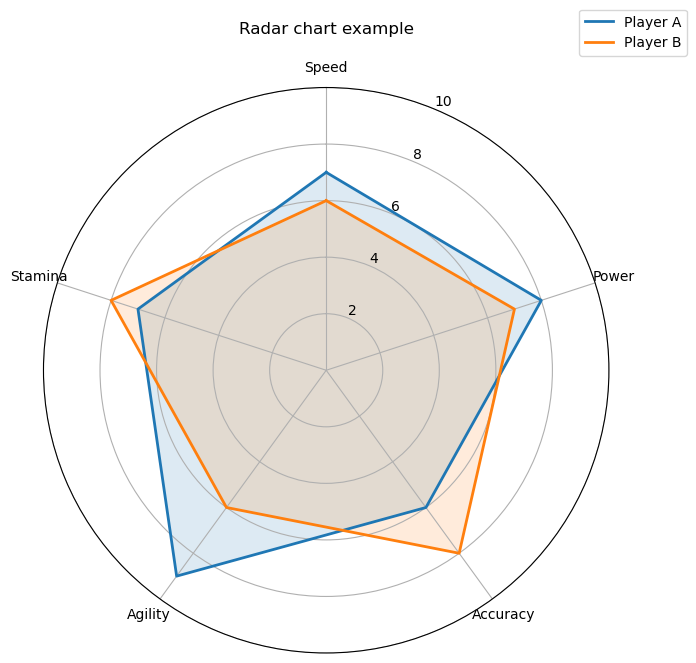

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def radar_chart(categories, series, *, title=None, rmin=0, rmax=None):
    """
    categories: list[str] (axis labels)
    series: list of dicts like [{"label": "...", "values": [...]}]
            values must match len(categories)
    """
    N = len(categories)
    if N < 3:
        raise ValueError("Radar charts usually need at least 3 categories.")

    # Angles for each axis, plus one extra to close the loop
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    # Put first axis at the top and go clockwise (common radar style)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Axis labels (one per category)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    # Radial limits
    if rmax is None:
        # derive rmax from data (a little padding)
        all_vals = [v for s in series for v in s["values"]]
        rmax = max(all_vals) * 1.1 if all_vals else 1
    ax.set_ylim(rmin, rmax)

    # Plot each series
    for s in series:
        vals = list(s["values"])
        if len(vals) != N:
            raise ValueError(f"Series '{s.get('label','')}' has {len(vals)} values; expected {N}.")
        vals += vals[:1]  # close the loop
        ax.plot(angles, vals, linewidth=2, label=s.get("label", None))
        ax.fill(angles, vals, alpha=0.15)

    if title:
        ax.set_title(title, pad=20)

    if any(s.get("label") for s in series):
        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.15))

    plt.tight_layout()
    return fig, ax

# --- Example usage ---
categories = ["Speed", "Power", "Accuracy", "Agility", "Stamina"]

series = [
    {"label": "Player A", "values": [7, 8, 6, 9, 7]},
    {"label": "Player B", "values": [6, 7, 8, 6, 8]},
]

radar_chart(categories, series, title="Radar chart example", rmin=0, rmax=10)
plt.show()
